In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load the data
df = pd.read_csv("/DataScinceExlr/Assignments/10. SVM/Pharma_Industry.csv")
df.shape

(500, 6)

#### Task 1: Exploratory Data Analysis (EDA) 

In [4]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [6]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [8]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

#### Since there are no missing values, the dataset appears to be complete and clean.

#### Task 2: Data Preprocessing

In [13]:
df["Drug Response"].value_counts

<bound method IndexOpsMixin.value_counts of 0      1
1      1
2      0
3      1
4      1
      ..
495    0
496    1
497    1
498    0
499    1
Name: Drug Response, Length: 500, dtype: int64>

In [17]:
df["Drug Response"].unique()

array([1, 0], dtype=int64)

<Figure size 1200x800 with 0 Axes>

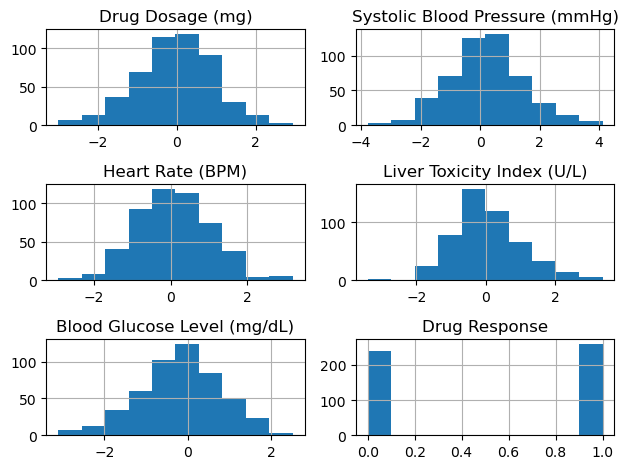

In [18]:
# plot histogram to visualize the distribution of the numerical features
plt.figure(figsize=(12, 8))
df.hist()
plt.tight_layout()
plt.show()


In [20]:
'''
All features appear to be approximately normally distributed. 
No significant skewness is observed, making the dataset well-suited for SVM modeling.
'''

'\nAll features appear to be approximately normally distributed. \nNo significant skewness is observed, making the dataset well-suited for SVM modeling.\n'

<Figure size 600x300 with 0 Axes>

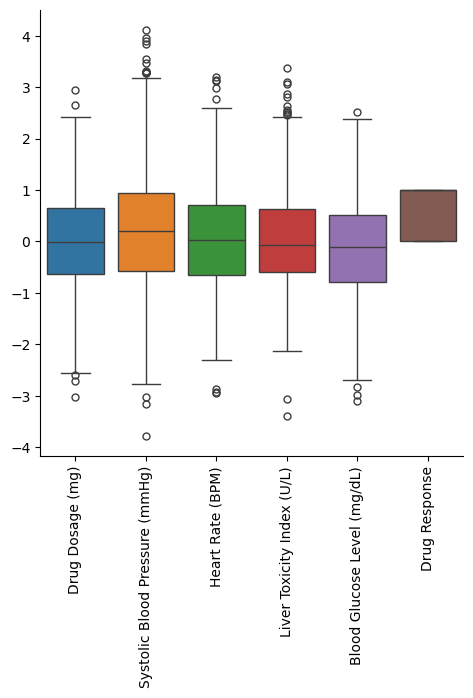

In [21]:
# finding outliers using boxplot
plt.figure(figsize=(6,3))
sns.catplot(df, kind='box')
plt.xticks(rotation=90)
plt.show()

#### Although a few outliers exist, SVM is robust enough to manage them efficiently.

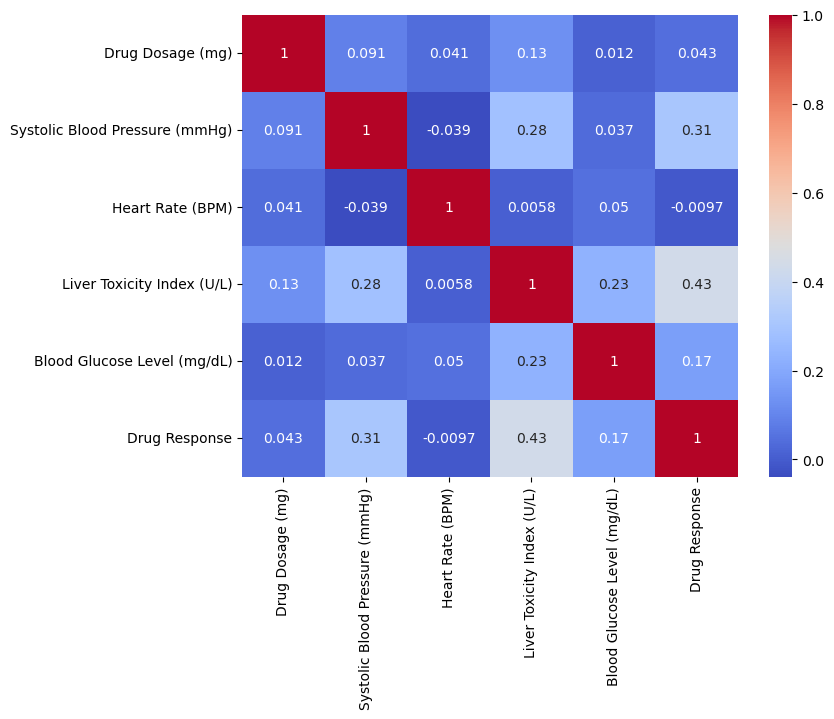

In [24]:
# Analyze the correlation between all input features and the target variable.
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

#### No extremely high correlations were found among the features, indicating low multicollinearity.

#### Task 2: Data Preprocessing 

In [25]:
# set features and traget variable
X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]

In [26]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

# Stratified splitting ensures that the class proportions
# remain consistent in both training and testing datasets.

((400, 5), (100, 5), (400,), (100,))

#### Task 3: Data Visualization 

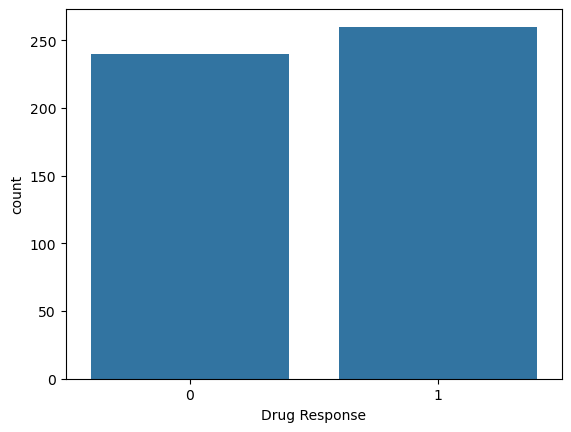

In [27]:
# Visualizing the class distribution to check whether the dataset is balanced
sns.countplot(x=y)
plt.show()

# The classes appear to be balanced; therefore, no resampling technique is required.

In [28]:
# The class distribution is nearly equal, indicating a balanced dataset.
# Hence, resampling methods such as oversampling or undersampling are not necessary.

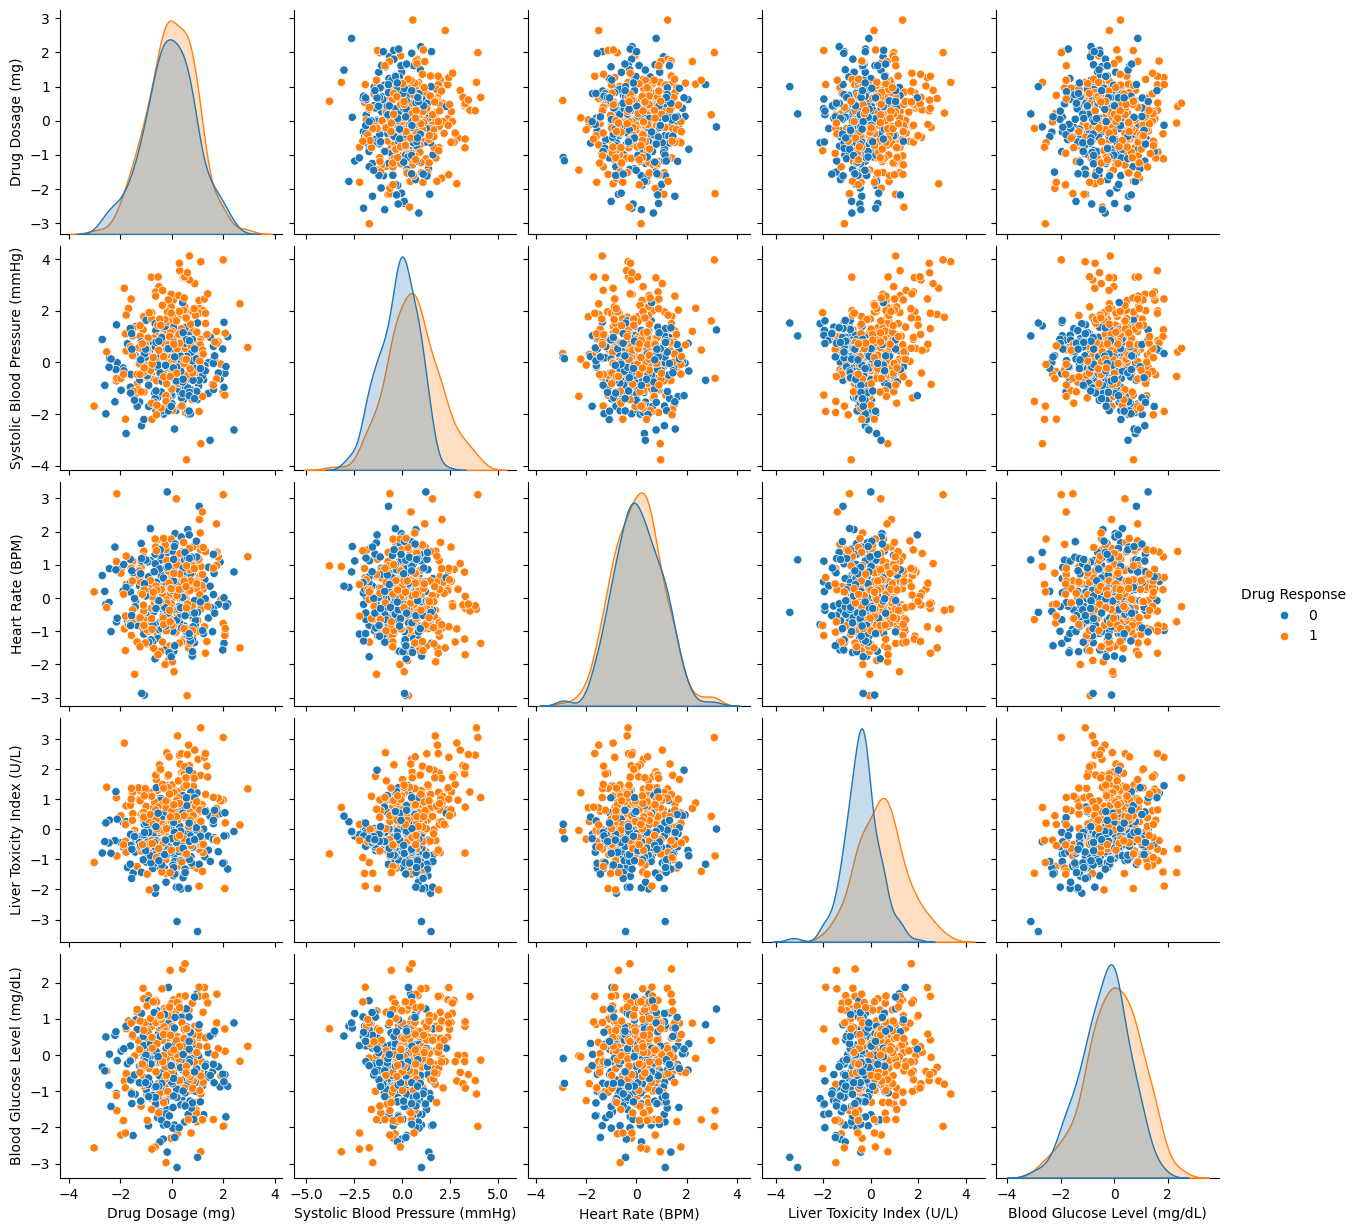

In [30]:
# Visualize the relationships between features
# and examine the degree of overlap between classes

sns.pairplot(df, hue="Drug Response")
plt.show()

#### There is partial overlap between the classes, which suggests the presence of non-linear decision boundaries.

#### Task 4:SVM Implementation

In [31]:
# Initialize the Support Vector Classifier with a linear kernel
# and train it using the training dataset

from sklearn.svm import SVC

svm_linear = SVC(kernel="linear", random_state=42)
svm_linear.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [32]:
# Evaluate the trained SVM model on the test dataset

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

yhat_test = svm_linear.predict(X_test)

print("Accuracy:", accuracy_score(y_test, yhat_test))
print("\nClassification Report:\n", classification_report(y_test, yhat_test))

Accuracy: 0.72

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



'''
The model’s ability to identify positive responders is reflected in the recall score, and the F1-score ensures a balanced evaluation of precision and recall.
'''

#### Task 5: Visualization of SVM Results 

In [37]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

In [38]:
# using two featrues
from sklearn.manifold import TSNE

In [39]:
tmodel = TSNE(n_components=2)
tcomps = tmodel.fit_transform(X, y)

In [36]:
#tcomps

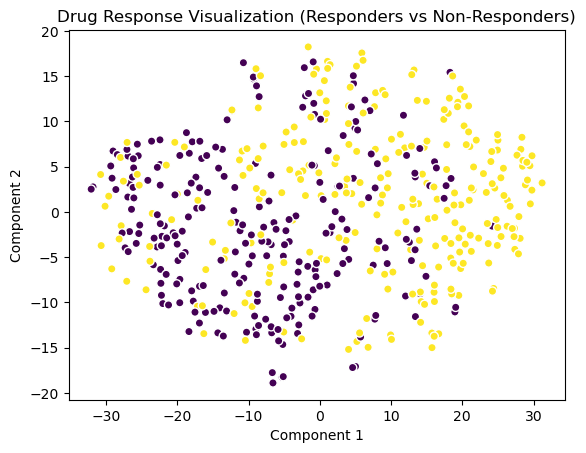

In [40]:
# Visualize drug response by plotting responding and non-responding patients

plt.scatter(tcomps[:, 0], tcomps[:, 1], c=y, cmap='viridis', edgecolors='white')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('Drug Response Visualization (Responders vs Non-Responders)')
plt.show()

In [42]:
# Visualize the dataset using an alternative dimensionality reduction approach (t-SNE)
tsne = TSNE(
    n_components=2,      # Reduce high-dimensional data to 2D for visualization
    perplexity=30,       # Balances local and global structure in the data
    random_state=42
)

X_tsne = tsne.fit_transform(X)

In [43]:
# Construct a structured DataFrame containing the two t-SNE components
# along with the corresponding drug response labels

tsne_df = pd.DataFrame({
    "TSNE_1": X_tsne[:, 0],
    "TSNE_2": X_tsne[:, 1],
    "Drug Response": y
})

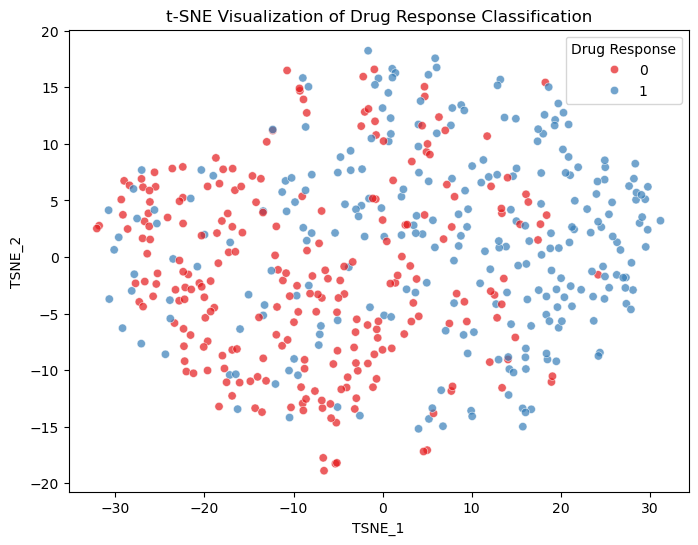

In [44]:
# Visualize the t-SNE projection to examine class separation
# between responding and non-responding patients

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=tsne_df,
    x="TSNE_1",
    y="TSNE_2",
    hue="Drug Response",
    palette="Set1",
    alpha=0.7
)

plt.title("t-SNE Visualization of Drug Response Classification")
plt.show()

#### Task 6: Parameter Tuning and Optimization 

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
# tune the parameters 
param_grid = {
    "C" : [0.1, 1, 10],
    "kernel" : ["linear", "rbf", "poly"],
    "gamma" : ["scale", "auto"]
}

In [47]:
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring="f1")

In [48]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='f1')

In [49]:
# Display the best-performing hyperparameter combination
# along with the highest cross-validation accuracy achieved

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best Cross-Validation Score: 0.7796554706594949


In [50]:
# Retrieve the best-performing SVM model from GridSearchCV
# and generate predictions on the test dataset

best_svm = grid.best_estimator_
y_best = best_svm.predict(X_test)

In [51]:
print(classification_report(y_test, y_best))

              precision    recall  f1-score   support

           0       0.73      0.67      0.70        48
           1       0.71      0.77      0.74        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



In [52]:
# Build the SVM model using the optimal hyperparameters
# (C=10, gamma='auto', kernel='rbf')

from sklearn.svm import SVC

svclf = SVC(C=10, gamma="auto", kernel="rbf")
svclf.fit(X_train, y_train)

SVC(C=10, gamma='auto')

In [53]:
tr = svclf.predict(X_train)

In [54]:
ts = svclf.predict(X_test)

In [55]:
print(classification_report(y_train, tr))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       192
           1       0.91      0.84      0.87       208

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.88      0.87      0.87       400



In [56]:
# check with confusion matrix
cm = confusion_matrix(y_train, tr)
cm

array([[175,  17],
       [ 34, 174]], dtype=int64)

In [57]:
print(classification_report(y_test, ts))

              precision    recall  f1-score   support

           0       0.73      0.67      0.70        48
           1       0.71      0.77      0.74        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



In [58]:
cm = confusion_matrix(y_test, yhat_test)
cm

array([[37, 11],
       [17, 35]], dtype=int64)

#### Task 7: Comparison and Analysis 

- Linear Kernel:
The performance is moderate, as it assumes that the data is linearly separable.

- Polynomial Kernel:
The performance is relatively heavier and may introduce complexity, increasing the risk of overfitting.

- RBF Kernel:
The RBF kernel shows the best performance, as it effectively captures complex and non-linear biological patterns in the dataset.

#### Strengths of SVM

- Performs well on standardized biomedical data.

- Effective in handling high-dimensional feature spaces and complex decision boundaries.

- Well-suited for drug response prediction tasks.

#### Weaknesses of SVM

- Computationally expensive for large datasets.

- Less interpretable in clinical settings compared to simpler models like decision trees or logistic regression.